In [1]:
import pandas as pd

transactions = pd.read_csv(
    "../data/processed/clean_transactions.csv",
    parse_dates=["InvoiceDate"]
)

print(transactions.shape)
print(transactions.head())
print(transactions.dtypes)

(397884, 9)
   InvoiceNo StockCode                          Description  Quantity  \
0     536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365     71053                  WHITE METAL LANTERN         6   
2     536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3     536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4     536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  Revenue  
0 2010-12-01 08:26:00       2.55       17850  United Kingdom    15.30  
1 2010-12-01 08:26:00       3.39       17850  United Kingdom    20.34  
2 2010-12-01 08:26:00       2.75       17850  United Kingdom    22.00  
3 2010-12-01 08:26:00       3.39       17850  United Kingdom    20.34  
4 2010-12-01 08:26:00       3.39       17850  United Kingdom    20.34  
InvoiceNo               int64
StockCode                 str
Description               str
Quantity                int

In [2]:
from lifetimes.utils import summary_data_from_transaction_data

rfm_model = summary_data_from_transaction_data(
    transactions,
    customer_id_col="CustomerID",
    datetime_col="InvoiceDate",
    monetary_value_col="Revenue",
    observation_period_end=transactions["InvoiceDate"].max()
)

print(rfm_model.shape)
print(rfm_model.head())
print(rfm_model.describe())

(4338, 4)
            frequency  recency      T  monetary_value
CustomerID                                           
12346             0.0      0.0  325.0        0.000000
12347             6.0    365.0  367.0      599.701667
12348             3.0    283.0  358.0      301.480000
12349             0.0      0.0   18.0        0.000000
12350             0.0      0.0  310.0        0.000000
         frequency      recency            T  monetary_value
count  4338.000000  4338.000000  4338.000000     4338.000000
mean      2.864223   130.771554   222.831028      307.028848
std       5.949000   132.210509   117.854570     2612.749850
min       0.000000     0.000000     0.000000        0.000000
25%       0.000000     0.000000   112.000000        0.000000
50%       1.000000    93.000000   248.000000      177.064773
75%       3.000000   252.000000   326.000000      360.162500
max     131.000000   373.000000   373.000000   168469.600000


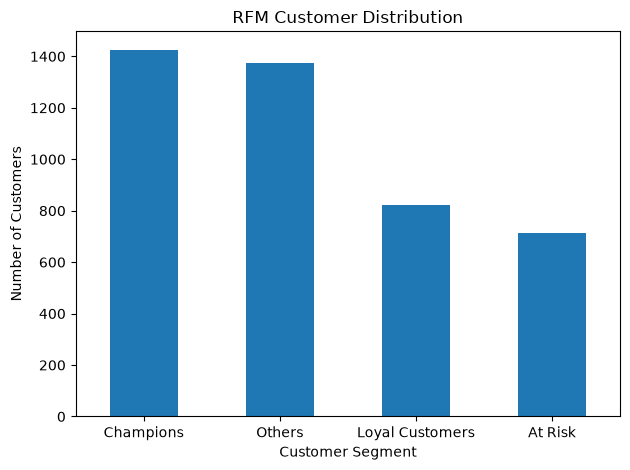

In [3]:
import matplotlib.pyplot as plt

customer_rfm = pd.read_csv("../data/processed/customer_rfm.csv")

segment_counts = customer_rfm["Segment"].value_counts()

segment_counts.plot(kind="bar")

plt.title("RFM Customer Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "../reports/rfm_customer_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [4]:
from lifetimes import BetaGeoFitter

bgf = BetaGeoFitter(penalizer_coef=0.0)

bgf.fit(
    rfm_model["frequency"],
    rfm_model["recency"],
    rfm_model["T"]
)

print(bgf.summary)

            coef   se(coef)  lower 95% bound  upper 95% bound
r       0.826542   0.026785         0.774044         0.879040
alpha  68.905121   2.611786        63.786020        74.024221
a       0.003437   0.010339        -0.016828         0.023702
b       6.745116  22.414725       -37.187745        50.677978


In [5]:
from lifetimes.utils import calibration_and_holdout_data
from lifetimes import BetaGeoFitter
from sklearn.metrics import mean_absolute_error

calibration_end = transactions["InvoiceDate"].max() - pd.Timedelta(days=30)

rfm_holdout = calibration_and_holdout_data(
    transactions,
    customer_id_col="CustomerID",
    datetime_col="InvoiceDate",
    calibration_period_end=calibration_end,
    observation_period_end=transactions["InvoiceDate"].max()
)

bgf_val = BetaGeoFitter(penalizer_coef=0.0)

bgf_val.fit(
    rfm_holdout["frequency_cal"],
    rfm_holdout["recency_cal"],
    rfm_holdout["T_cal"]
)

rfm_holdout["predicted_purchases"] = bgf_val.predict(
    30,
    rfm_holdout["frequency_cal"],
    rfm_holdout["recency_cal"],
    rfm_holdout["T_cal"]
)

mae = mean_absolute_error(
    rfm_holdout["frequency_holdout"],
    rfm_holdout["predicted_purchases"]
)

print("Holdout MAE:", round(mae, 4))
print(rfm_holdout[["frequency_holdout", "predicted_purchases"]].head())

Holdout MAE: 0.5138
            frequency_holdout  predicted_purchases
CustomerID                                        
12346                     0.0             0.065934
12347                     1.0             0.425770
12348                     0.0             0.285406
12350                     0.0             0.068742
12352                     0.0             0.603881


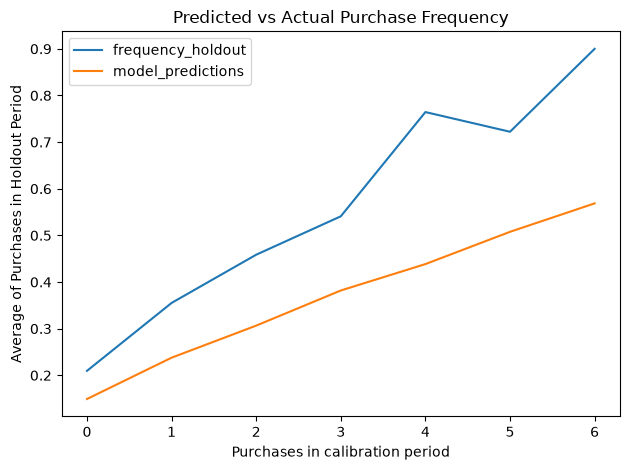

In [6]:
import matplotlib.pyplot as plt
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases

plot_calibration_purchases_vs_holdout_purchases(
    bgf_val,
    rfm_holdout
)

plt.title("Predicted vs Actual Purchase Frequency")
plt.tight_layout()
plt.savefig(
    "../reports/predicted_vs_actual_purchase_frequency.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [7]:
from lifetimes import GammaGammaFitter

returning_customers = rfm_model[
    (rfm_model["frequency"] > 0)
    & (rfm_model["monetary_value"] > 0)
].copy()

ggf = GammaGammaFitter(penalizer_coef=0.0)

ggf.fit(
    returning_customers["frequency"],
    returning_customers["monetary_value"]
)

print("Returning customers:", len(returning_customers))
print(ggf.summary)

Returning customers: 2790
         coef   se(coef)  lower 95% bound  upper 95% bound
p    2.103382   0.111959         1.883943         2.322821
q    3.451179   0.139105         3.178533         3.723825
v  485.888595  42.616487       402.360280       569.416909


In [8]:
rfm_model["predicted_purchases_90d"] = bgf.predict(
    90,
    rfm_model["frequency"],
    rfm_model["recency"],
    rfm_model["T"]
)

print(
    rfm_model[
        ["frequency", "recency", "T", "predicted_purchases_90d"]
    ].head()
)

print("\n90-day purchase prediction summary:")
print(rfm_model["predicted_purchases_90d"].describe())

            frequency  recency      T  predicted_purchases_90d
CustomerID                                                    
12346             0.0      0.0  325.0                 0.188830
12347             6.0    365.0  367.0                 1.408736
12348             3.0    283.0  358.0                 0.805907
12349             0.0      0.0   18.0                 0.855607
12350             0.0      0.0  310.0                 0.196304

90-day purchase prediction summary:
count    4338.000000
mean        1.077029
std         1.268440
min         0.168321
25%         0.450993
50%         0.765835
75%         1.269444
max        26.838843
Name: predicted_purchases_90d, dtype: float64


In [9]:
rfm_model["expected_avg_value"] = ggf.conditional_expected_average_profit(
    rfm_model["frequency"],
    rfm_model["monetary_value"]
)

rfm_model["predicted_clv_90d"] = (
    rfm_model["predicted_purchases_90d"]
    * rfm_model["expected_avg_value"]
)

print(
    rfm_model[
        ["predicted_purchases_90d", "expected_avg_value", "predicted_clv_90d"]
    ].head()
)

print("\n90-day CLV summary:")
print(rfm_model["predicted_clv_90d"].describe())

            predicted_purchases_90d  expected_avg_value  predicted_clv_90d
CustomerID                                                                
12346                      0.188830          416.946028          78.731889
12347                      1.408736          569.978836         802.949444
12348                      0.805907          333.784235         268.999175
12349                      0.855607          416.946028         356.742132
12350                      0.196304          416.946028          81.848381

90-day CLV summary:
count     4338.000000
mean       531.643614
std       1899.329899
min         70.180754
25%        158.244826
50%        274.293787
75%        465.360792
max      59249.011124
Name: predicted_clv_90d, dtype: float64


In [10]:
customer_rfm = pd.read_csv("../data/processed/customer_rfm.csv")

segment_map = customer_rfm.set_index("CustomerID")["Segment"]

rfm_model["Segment"] = rfm_model.index.map(segment_map)

print(rfm_model["Segment"].value_counts())
print(rfm_model.head())

Segment
Champions          1426
Others             1375
Loyal Customers     822
At Risk             715
Name: count, dtype: int64
            frequency  recency      T  monetary_value  \
CustomerID                                              
12346             0.0      0.0  325.0        0.000000   
12347             6.0    365.0  367.0      599.701667   
12348             3.0    283.0  358.0      301.480000   
12349             0.0      0.0   18.0        0.000000   
12350             0.0      0.0  310.0        0.000000   

            predicted_purchases_90d  expected_avg_value  predicted_clv_90d  \
CustomerID                                                                   
12346                      0.188830          416.946028          78.731889   
12347                      1.408736          569.978836         802.949444   
12348                      0.805907          333.784235         268.999175   
12349                      0.855607          416.946028         356.742132   
12

In [11]:
customer_clv = rfm_model.reset_index()

customer_clv.to_csv(
    "../data/processed/customer_clv.csv",
    index=False
)

print(customer_clv.shape)
print(customer_clv.head())
print("\nSaved: ../data/processed/customer_clv.csv")

(4338, 9)
   CustomerID  frequency  recency      T  monetary_value  \
0       12346        0.0      0.0  325.0        0.000000   
1       12347        6.0    365.0  367.0      599.701667   
2       12348        3.0    283.0  358.0      301.480000   
3       12349        0.0      0.0   18.0        0.000000   
4       12350        0.0      0.0  310.0        0.000000   

   predicted_purchases_90d  expected_avg_value  predicted_clv_90d    Segment  
0                 0.188830          416.946028          78.731889    At Risk  
1                 1.408736          569.978836         802.949444  Champions  
2                 0.805907          333.784235         268.999175    At Risk  
3                 0.855607          416.946028         356.742132     Others  
4                 0.196304          416.946028          81.848381     Others  

Saved: ../data/processed/customer_clv.csv


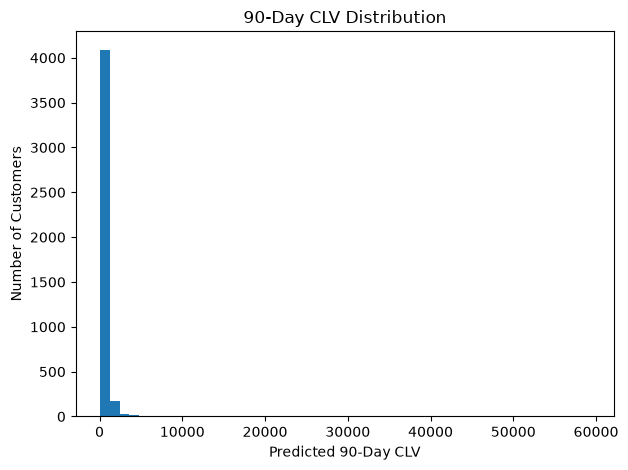

In [12]:
plt.hist(customer_clv["predicted_clv_90d"], bins=50)

plt.title("90-Day CLV Distribution")
plt.xlabel("Predicted 90-Day CLV")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.savefig(
    "../reports/clv_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

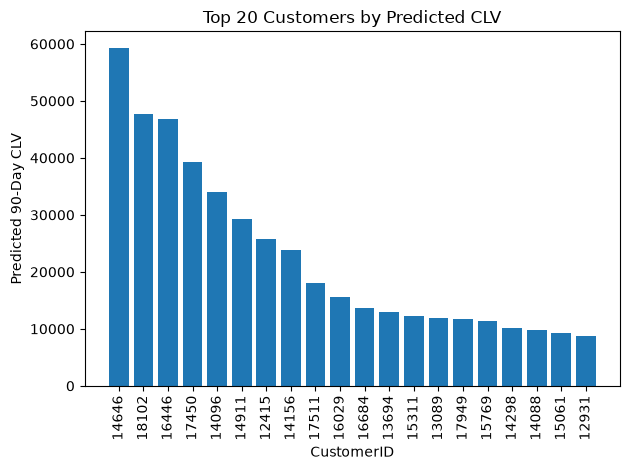

In [13]:
top_customers = customer_clv.nlargest(20, "predicted_clv_90d")

plt.bar(
    top_customers["CustomerID"].astype(str),
    top_customers["predicted_clv_90d"]
)

plt.title("Top 20 Customers by Predicted CLV")
plt.xlabel("CustomerID")
plt.ylabel("Predicted 90-Day CLV")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    "../reports/top_customers_by_clv.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()